In [8]:
import requests
import pandas as pd
import time
from tqdm import tqdm
from urllib.parse import unquote

WIKIPEDIA_URL = "https://en.wikipedia.org/w/api.php"
WIKIDATA_SPARQL_URL = "https://query.wikidata.org/sparql"

HEADERS = {
    "User-Agent": "DTU-Student-Project/1.0 (miapaarup@gmail.com)"
}

FEMALE = "Q6581072"
MALE = "Q6581097"

FIELDS = {
    "computer_scientist": "Q82594",
    "physicist": "Q169470",
    "chemist": "Q593644",
    "mathematician": "Q170790",
    "biologist": "Q864503",
}


def query_wikidata_by_field(gender_qid, occupation_qid, field_name, limit=100, retries=3):
    """
    Query Wikidata for people with:
    - selected gender
    - selected occupation
    - English Wikipedia article
    """

    query = f"""
    SELECT ?person ?personLabel ?article WHERE {{
      ?person wdt:P31 wd:Q5;
              wdt:P21 wd:{gender_qid};
              wdt:P106 wd:{occupation_qid}.

      ?article schema:about ?person;
               schema:isPartOf <https://en.wikipedia.org/>.

      SERVICE wikibase:label {{
        bd:serviceParam wikibase:language "en".
      }}
    }}
    LIMIT {limit}
    """

    params = {"query": query, "format": "json"}

    for attempt in range(retries):
        try:
            response = requests.get(
                WIKIDATA_SPARQL_URL,
                params=params,
                headers=HEADERS,
                timeout=90
            )

            print(f"{field_name} | {gender_qid} | attempt {attempt + 1} | status: {response.status_code}")

            if response.status_code != 200:
                print(response.text[:500])
                time.sleep(5)
                continue

            data = response.json()
            rows = []

            for item in data["results"]["bindings"]:
                article_url = item["article"]["value"]

                # Convert Wikipedia URL into clean article title
                title = article_url.split("/wiki/")[-1]
                title = unquote(title)
                title = title.replace("_", " ")

                rows.append({
                    "person": item["person"]["value"],
                    "name": item["personLabel"]["value"],
                    "article_url": article_url,
                    "title": title,
                    "field": field_name
                })

            return pd.DataFrame(rows)

        except requests.exceptions.RequestException as e:
            print(f"Request failed: {e}")
            time.sleep(10)

    return pd.DataFrame()


def get_page_text(title, retries=3):
    """
    Fetch one Wikipedia article text.

    This is less clever than batching, but more reliable.
    """

    params = {
        "action": "query",
        "prop": "extracts",
        "explaintext": True,
        "titles": title,
        "format": "json",
        "redirects": 1
    }

    for attempt in range(retries):
        try:
            response = requests.get(
                WIKIPEDIA_URL,
                params=params,
                headers=HEADERS,
                timeout=60
            )

            if response.status_code != 200:
                print(f"Wikipedia error for {title}: {response.status_code}")
                time.sleep(5)
                continue

            data = response.json()
            pages = data["query"]["pages"]

            for page in pages.values():
                return page.get("extract", "")

        except requests.exceptions.RequestException as e:
            print(f"Request failed for {title}: {e}")
            time.sleep(5)

    return ""


# -------------------------------
# 1. Collect people from Wikidata
# -------------------------------

all_people = []

PEOPLE_PER_FIELD_GENDER = 300

for field_name, occupation_qid in FIELDS.items():

    women_field = query_wikidata_by_field(
        gender_qid=FEMALE,
        occupation_qid=occupation_qid,
        field_name=field_name,
        limit=PEOPLE_PER_FIELD_GENDER
    )
    women_field["gender_group"] = "women"

    men_field = query_wikidata_by_field(
        gender_qid=MALE,
        occupation_qid=occupation_qid,
        field_name=field_name,
        limit=PEOPLE_PER_FIELD_GENDER
    )
    men_field["gender_group"] = "men"

    all_people.append(women_field)
    all_people.append(men_field)

    time.sleep(1)

people = pd.concat(all_people, ignore_index=True)
people = people.drop_duplicates(subset=["person"]).reset_index(drop=True)

print("\nCounts before fetching text:")
print(people.groupby(["field", "gender_group"]).size())


# -------------------------------
# 2. Fetch article texts one by one
# -------------------------------

texts = []

print("\n--- Fetching article texts one by one ---")

for _, row in tqdm(people.iterrows(), total=len(people)):
    text = get_page_text(row["title"])
    texts.append(text)

    # Polite pause so we do not spam the API
    time.sleep(0.1)

people["text"] = texts
people["text_length"] = people["text"].str.len()
people["word_count"] = people["text"].str.split().str.len()

print("\nText fetching diagnostics:")
print("Total people:", len(people))
print("Articles with empty text:", (people["word_count"] == 0).sum())
print("Articles with at least 500 words:", (people["word_count"] >= 500).sum())


# -------------------------------
# 3. Filter short articles
# -------------------------------

MIN_WORDS = 500

people_filtered = people[people["word_count"] >= MIN_WORDS].copy()

print("\nCounts after filtering short articles:")
print(people_filtered.groupby(["field", "gender_group"]).size())

print("\nFiltered dataset preview:")
print(people_filtered[["name", "gender_group", "field", "title", "word_count"]])


# -------------------------------
# 4. Save full filtered dataset
# -------------------------------

people_filtered.to_csv("scientist_biographies_wikipedia.csv", index=False)

print("\nSaved dataset as scientist_biographies_wikipedia.csv")
print("Total articles kept:", len(people_filtered))
print("Total words:", people_filtered["word_count"].sum())
print("Average words per article:", people_filtered["word_count"].mean())


# -------------------------------
# 5. Create balanced dataset
# -------------------------------

available_counts = people_filtered.groupby(["field", "gender_group"]).size()

print("\nAvailable biographies per field/gender:")
print(available_counts)

N_PER_GROUP = available_counts.min()

print("\nBalancing to this many biographies per field/gender:")
print(N_PER_GROUP)

balanced_people = (
    people_filtered
    .groupby(["field", "gender_group"], group_keys=False)
    .apply(lambda x: x.sample(n=N_PER_GROUP, random_state=42))
    .reset_index(drop=True)
)

balanced_people.to_csv("balanced_scientist_biographies_wikipedia.csv", index=False)

print("\nSaved balanced dataset as balanced_scientist_biographies_wikipedia.csv")

print("\nBalanced dataset counts:")
print(balanced_people.groupby(["field", "gender_group"]).size())

print("\nFinal balanced dataset size:", len(balanced_people))
print("Total words in balanced dataset:", balanced_people["word_count"].sum())

computer_scientist | Q6581072 | attempt 1 | status: 200
computer_scientist | Q6581097 | attempt 1 | status: 200
physicist | Q6581072 | attempt 1 | status: 200
physicist | Q6581097 | attempt 1 | status: 200
chemist | Q6581072 | attempt 1 | status: 200
chemist | Q6581097 | attempt 1 | status: 200
mathematician | Q6581072 | attempt 1 | status: 200
mathematician | Q6581097 | attempt 1 | status: 200
biologist | Q6581072 | attempt 1 | status: 200
biologist | Q6581097 | attempt 1 | status: 200

Counts before fetching text:
field               gender_group
biologist           men              97
                    women            94
chemist             men              97
                    women            87
computer_scientist  men             100
                    women           100
mathematician       men              86
                    women            65
physicist           men              99
                    women            96
dtype: int64

--- Fetching article texts one 

100%|██████████| 921/921 [21:52<00:00,  1.42s/it]  



Text fetching diagnostics:
Total people: 921
Articles with empty text: 0
Articles with at least 500 words: 604

Counts after filtering short articles:
field               gender_group
biologist           men             53
                    women           68
chemist             men             59
                    women           65
computer_scientist  men             67
                    women           70
mathematician       men             49
                    women           41
physicist           men             60
                    women           72
dtype: int64

Filtered dataset preview:
                      name gender_group               field  \
0    Erna Schneider Hoover        women  computer_scientist   
1          Mary Lou Jepsen        women  computer_scientist   
2           Marlyn Meltzer        women  computer_scientist   
3            Ginni Rometty        women  computer_scientist   
4             Ada Lovelace        women  computer_scientist   
..     

C:\Users\miapa\AppData\Local\Temp\ipykernel_28136\1357182311.py:246: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=N_PER_GROUP, random_state=42))


In [9]:
import re
import itertools
import pandas as pd
import networkx as nx
import nltk

from nltk.corpus import stopwords
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

# Download NLTK stopwords once
nltk.download("stopwords")

# Load English stopwords from NLTK
nltk_stop_words = set(stopwords.words("english"))

# Optional: load your balanced dataset if not already loaded
# balanced_people = pd.read_csv("balanced_scientist_biographies_wikipedia.csv")


# ----------------------------------------------------
# 1. Remove non-biographical Wikipedia sections
# ----------------------------------------------------

def remove_bad_sections(text):
    """
    Remove Wikipedia sections that are usually not part of the biography itself.

    This helps avoid analyzing reference lists, publication lists,
    external links, bibliography sections, etc.
    """

    bad_sections = {
        "references",
        "bibliography",
        "further reading",
        "external links",
        "see also",
        "notes",
        "sources",
        "works cited",
        "selected publications",
        "publications",
        "books",
        "awards and honors"
    }

    lines = str(text).split("\n")
    keep_lines = []
    skip = False

    for line in lines:
        clean_line = line.strip().lower()

        # Wikipedia section headings often look like: == References ==
        if clean_line.startswith("==") and clean_line.endswith("=="):
            section_name = clean_line.replace("=", "").strip()

            if section_name in bad_sections:
                skip = True
                continue
            else:
                skip = False

        if not skip:
            keep_lines.append(line)

    return "\n".join(keep_lines)


# ----------------------------------------------------
# 2. Remove the biography subject's own name
# ----------------------------------------------------

def remove_title_words(text, title):
    """
    Remove words from the article title.

    Example:
    'Ada Lovelace' -> removes 'ada' and 'lovelace'.

    This prevents the person's own name from dominating the analysis.
    """

    title_words = re.sub(r"[^a-zA-Z\s]", " ", str(title)).lower().split()

    for word in title_words:
        if len(word) > 2:
            text = re.sub(rf"\b{word}\b", " ", str(text), flags=re.IGNORECASE)

    return text


# ----------------------------------------------------
# 3. Basic cleaning
# ----------------------------------------------------

def clean_text(text):
    """
    Clean raw text before tokenization.

    Steps:
    - lowercase
    - remove remaining Wikipedia headings
    - keep only letters and spaces
    - collapse repeated spaces
    """

    text = str(text).lower()
    text = re.sub(r"==.*?==", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


# ----------------------------------------------------
# 4. Define stopwords
# ----------------------------------------------------

CUSTOM_STOPWORDS = nltk_stop_words.union({
    # Wikipedia / citation noise
    "isbn", "doi", "pmid", "retrieved", "archive", "archived",
    "http", "https", "www", "org", "com",

    # Common non-English filler words sometimes appearing in names/titles
    "der", "die", "das", "und", "von", "zur", "mit",

    # Generic biography words
    "said", "called", "known", "including",
    "life", "year", "years", "time", "new", "world",
    "born", "died", "early", "later", "people",

    # Too general for your analysis
    "work", "works", "published", "wikipedia", "th"
})


# ----------------------------------------------------
# 5. Tokenization + stopword removal
# ----------------------------------------------------

def tokenize_and_remove_stopwords(text):
    """
    Standard NLP step:
    1. Tokenize text into words
    2. Remove stopwords
    3. Remove very short tokens

    Output:
    list of cleaned tokens
    """

    tokens = str(text).split()

    tokens = [
        word for word in tokens
        if word not in CUSTOM_STOPWORDS
        and len(word) > 2
    ]

    return tokens


# ----------------------------------------------------
# 6. Full preprocessing pipeline
# ----------------------------------------------------

def preprocess_article(text, title):
    """
    Full NLP preprocessing pipeline for one biography.

    Pipeline:
    raw text
    -> remove unwanted Wikipedia sections
    -> remove subject's own name
    -> clean text
    -> tokenize
    -> remove stopwords
    """

    text = remove_bad_sections(text)
    text = remove_title_words(text, title)
    text = clean_text(text)
    tokens = tokenize_and_remove_stopwords(text)

    return tokens


# Apply full preprocessing to every biography
balanced_people["tokens"] = balanced_people.apply(
    lambda row: preprocess_article(row["text"], row["title"]),
    axis=1
)

# Create a cleaned string version too
# This is useful for TF-IDF, because TfidfVectorizer expects text strings
balanced_people["clean_text"] = balanced_people["tokens"].apply(lambda tokens: " ".join(tokens))


# ----------------------------------------------------
# 7. Quick diagnostics
# ----------------------------------------------------

balanced_people["clean_word_count"] = balanced_people["tokens"].apply(len)

print("Preprocessing complete.")
print("Average cleaned words per biography:", balanced_people["clean_word_count"].mean())
print("Minimum cleaned words:", balanced_people["clean_word_count"].min())
print("Maximum cleaned words:", balanced_people["clean_word_count"].max())

print("\nPreview:")
print(balanced_people[["name", "gender_group", "field", "title", "clean_word_count"]].head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\miapa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Preprocessing complete.
Average cleaned words per biography: 871.3487804878049
Minimum cleaned words: 89
Maximum cleaned words: 7513

Preview:
                     name gender_group      field                   title  \
0      Walter M. Elsasser          men  biologist      Walter M. Elsasser   
1           Thomas S. Ray          men  biologist           Thomas S. Ray   
2  Friedrich Wilhelm Zopf          men  biologist  Friedrich Wilhelm Zopf   
3         Richard Hertwig          men  biologist         Richard Hertwig   
4           Vernon Ingram          men  biologist           Vernon Ingram   

   clean_word_count  
0               573  
1               987  
2               293  
3               334  
4               234  


Det der freuency og historgram

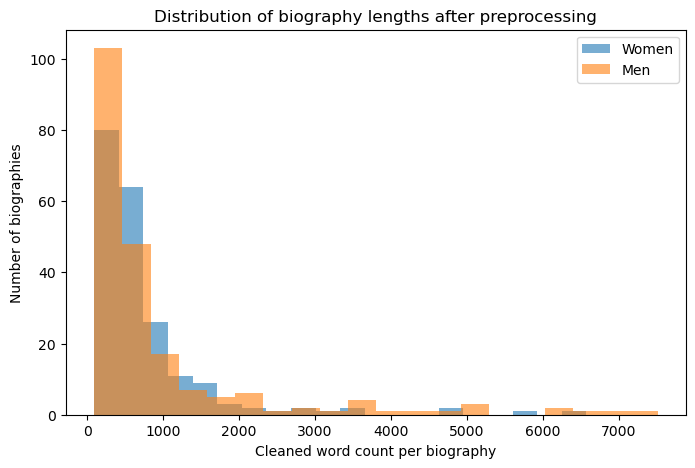

Average cleaned word count by gender:
              count        mean  median  min   max
gender_group                                      
men             205  968.253659   460.0   92  7513
women           205  774.443902   508.0   89  6573


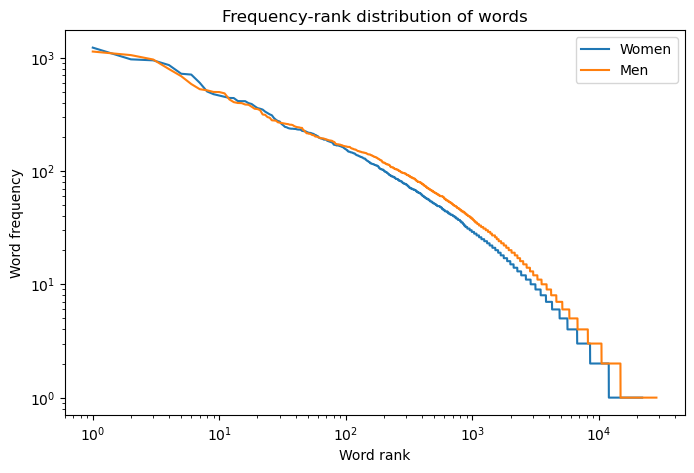


Top 20 words in women biographies:
[('university', 1226), ('research', 966), ('first', 947), ('science', 860), ('women', 721), ('also', 709), ('one', 600), ('became', 503), ('school', 476), ('american', 463), ('college', 452), ('professor', 441), ('society', 440), ('national', 414), ('two', 413), ('computer', 413), ('award', 397), ('chemistry', 390), ('institute', 373), ('mathematics', 359)]

Top 20 words in men biographies:
[('university', 1132), ('also', 1053), ('first', 963), ('one', 793), ('theory', 686), ('became', 585), ('would', 527), ('research', 515), ('german', 498), ('science', 497), ('two', 484), ('could', 428), ('mathematics', 405), ('professor', 398), ('made', 397), ('physics', 386), ('institute', 384), ('system', 369), ('many', 354), ('used', 352)]

Gendered word usage by gender:
             gendered_word_count              gendered_word_rate            \
                            mean median   sum               mean    median   
gender_group                         

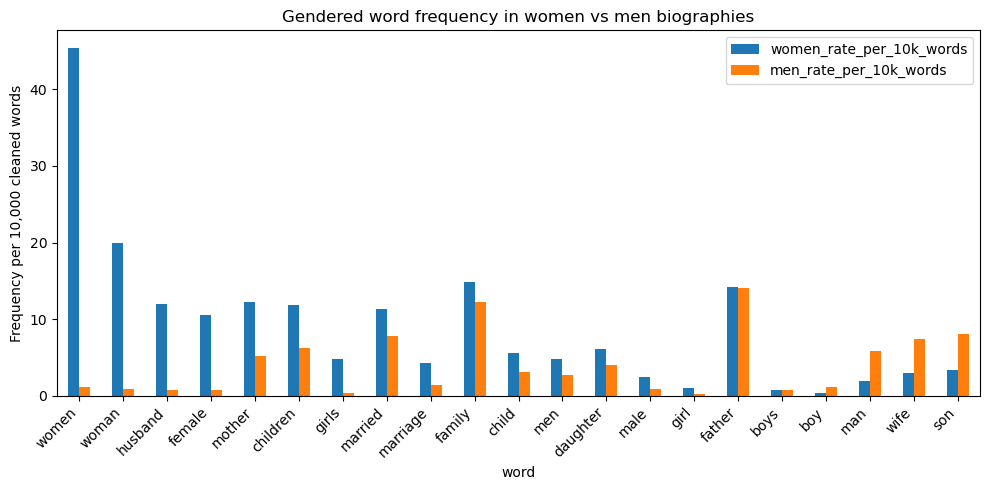


Saved file:
gendered_word_frequency_comparison.csv


In [20]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter


# ====================================================
# 8. Descriptive check: biography length by gender
# ====================================================

plt.figure(figsize=(8, 5))

plt.hist(
    balanced_people[balanced_people["gender_group"] == "women"]["clean_word_count"],
    bins=20,
    alpha=0.6,
    label="Women"
)

plt.hist(
    balanced_people[balanced_people["gender_group"] == "men"]["clean_word_count"],
    bins=20,
    alpha=0.6,
    label="Men"
)

plt.xlabel("Cleaned word count per biography")
plt.ylabel("Number of biographies")
plt.title("Distribution of biography lengths after preprocessing")
plt.legend()
plt.show()


print("Average cleaned word count by gender:")
print(
    balanced_people
    .groupby("gender_group")["clean_word_count"]
    .agg(["count", "mean", "median", "min", "max"])
)


# ====================================================
# 9. Frequency-rank plot
# ====================================================

def get_word_frequencies(df):
    """
    Combine all tokens in a dataframe and count word frequencies.
    """

    all_words = []

    for tokens in df["tokens"]:
        all_words.extend(tokens)

    return Counter(all_words)


women_freq = get_word_frequencies(
    balanced_people[balanced_people["gender_group"] == "women"]
)

men_freq = get_word_frequencies(
    balanced_people[balanced_people["gender_group"] == "men"]
)


def plot_frequency_rank(counter, label):
    """
    Plot word frequency by rank.

    Rank 1 = most frequent word.
    """

    frequencies = sorted(counter.values(), reverse=True)
    ranks = range(1, len(frequencies) + 1)

    plt.plot(ranks, frequencies, label=label)


plt.figure(figsize=(8, 5))

plot_frequency_rank(women_freq, "Women")
plot_frequency_rank(men_freq, "Men")

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Word rank")
plt.ylabel("Word frequency")
plt.title("Frequency-rank distribution of words")
plt.legend()
plt.show()


print("\nTop 20 words in women biographies:")
print(women_freq.most_common(20))

print("\nTop 20 words in men biographies:")
print(men_freq.most_common(20))


# ====================================================
# 10. Gendered word frequency analysis
# ====================================================

gendered_words = [
    "woman", "women", "female", "girl", "girls",
    "man", "men", "male", "boy", "boys",
    "mother", "father",
    "wife", "husband",
    "married", "marriage",
    "children", "child",
    "family", "daughter", "son"
]


def count_selected_words(tokens, selected_words):
    """
    Count how many times selected words appear in one biography.
    """

    return sum(1 for word in tokens if word in selected_words)


balanced_people["gendered_word_count"] = balanced_people["tokens"].apply(
    lambda tokens: count_selected_words(tokens, gendered_words)
)

balanced_people["gendered_word_rate"] = (
    balanced_people["gendered_word_count"] /
    balanced_people["clean_word_count"]
)


print("\nGendered word usage by gender:")
print(
    balanced_people
    .groupby("gender_group")[["gendered_word_count", "gendered_word_rate"]]
    .agg(["mean", "median", "sum"])
)


# Count each gendered word separately for women and men
rows = []

for word in gendered_words:
    rows.append({
        "word": word,
        "women_count": women_freq.get(word, 0),
        "men_count": men_freq.get(word, 0)
    })

gendered_freq_df = pd.DataFrame(rows)

# Normalize by total number of cleaned words in each group
women_total_words = sum(women_freq.values())
men_total_words = sum(men_freq.values())

gendered_freq_df["women_rate_per_10k_words"] = (
    gendered_freq_df["women_count"] / women_total_words * 10000
)

gendered_freq_df["men_rate_per_10k_words"] = (
    gendered_freq_df["men_count"] / men_total_words * 10000
)

gendered_freq_df["difference_women_minus_men"] = (
    gendered_freq_df["women_rate_per_10k_words"] -
    gendered_freq_df["men_rate_per_10k_words"]
)

gendered_freq_df = gendered_freq_df.sort_values(
    "difference_women_minus_men",
    ascending=False
)

print("\nGendered word frequencies:")
print(gendered_freq_df)


# Bar plot of normalized gendered word frequency
gendered_freq_df.plot(
    x="word",
    y=["women_rate_per_10k_words", "men_rate_per_10k_words"],
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("Frequency per 10,000 cleaned words")
plt.title("Gendered word frequency in women vs men biographies")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# Save result
gendered_freq_df.to_csv("gendered_word_frequency_comparison.csv", index=False)

print("\nSaved file:")
print("gendered_word_frequency_comparison.csv")

Text -> TD-IDF -> network -> clean network -> community detection -> interpreation 

## Building semantic co-occurrence networks

In this part of the analysis, we move from individual biography texts to semantic networks. The goal is to study not only which words appear often, but also which words tend to appear together. This lets us compare the structure of language in biographies of women and men scientists.

### Step 1: Selecting meaningful words with TF-IDF

We first use TF-IDF to identify important words across the cleaned biographies. TF-IDF gives higher scores to words that are common in some biographies but not simply common everywhere. This helps us avoid building a network from very generic words.

We keep the top 400 TF-IDF words as a shared vocabulary. This vocabulary is used for both the women’s and men’s networks, so the two networks are based on the same set of possible words and are therefore more comparable.

The parameters are chosen to reduce noise:

- `min_df=2`: a word must appear in at least two biographies, so very rare words are removed.
- `max_df=0.6`: words appearing in more than 60% of biographies are removed because they are likely too general.
- `max_features=400`: we keep a manageable number of important words.

### Step 2: Using paragraphs as co-occurrence windows

To build the network, we split each biography into paragraphs. A paragraph is treated as a local context: if two important words appear in the same paragraph, we assume they are semantically related in that biography.

This is more meaningful than connecting words that appear anywhere in the same biography, because a full biography can cover many unrelated topics. Paragraph-level co-occurrence gives a more local and interpretable measure of association.

### Step 3: Building the network

Each network is built as a weighted, undirected graph:

- Nodes are important TF-IDF words.
- Edges connect words that appear in the same paragraph.
- Edge weight counts how many times two words co-occur across paragraphs.

We build one network for biographies of women scientists and one for biographies of men scientists. This allows us to compare whether the semantic structure differs between the two groups.

Within each paragraph, we only use unique words. This means that if a word appears many times in the same paragraph, it does not create repeated edges. This avoids overemphasizing repeated wording inside a single paragraph.

We also skip paragraphs with too few or too many selected words. Very sparse paragraphs do not contain enough information to create meaningful connections, while very dense paragraphs can create too many edges and make the network noisy.

### Step 4: Removing weak edges

After building the networks, we remove edges with weight below 2. This means that a pair of words must co-occur at least twice to remain in the network.

This filtering makes the network easier to interpret by removing one-off connections that may be accidental or unimportant. Isolated nodes are also removed because they no longer contribute to the network structure.

### Step 5: Network summaries

We then print basic network statistics such as the number of nodes, number of edges, average degree, and top words by weighted degree.

Weighted degree, also called node strength, measures how strongly connected a word is to other words. A high-strength word is not just frequent; it is connected to many other important words through repeated co-occurrence.

### Step 6: Community detection

Finally, we apply Louvain community detection. In this semantic network, communities are groups of words that frequently co-occur with each other. These communities can be interpreted as themes or topics in the biographies.

For example, one community might contain words related to education and academic careers, while another might contain words related to awards, discoveries, or personal life.

The community labels are added to the network so they can later be used for visualization, for example by coloring nodes according to their community.

In [12]:
import re
import itertools
import pandas as pd
import networkx as nx

from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from networkx.algorithms.community import louvain_communities


# ----------------------------------------------------
# 1. Get shared TF-IDF vocabulary
# ----------------------------------------------------

def get_top_tfidf_words(texts, max_features=400):
    """
    Find important shared words using TF-IDF.

    These words become the vocabulary for the semantic network.
    """

    vectorizer = TfidfVectorizer(
        stop_words=list(CUSTOM_STOPWORDS),
        min_df=2,
        max_df=0.6,
        max_features=max_features
    )

    tfidf_matrix = vectorizer.fit_transform(texts)

    words = vectorizer.get_feature_names_out()
    mean_scores = tfidf_matrix.mean(axis=0).A1

    tfidf_df = pd.DataFrame({
        "word": words,
        "tfidf_score": mean_scores
    }).sort_values("tfidf_score", ascending=False)

    return tfidf_df, set(tfidf_df["word"])


tfidf_df, shared_vocab = get_top_tfidf_words(
    balanced_people["clean_text"],
    max_features=400
)

print("Top shared TF-IDF words:")
print(tfidf_df.head(30))


# ----------------------------------------------------
# 2. Split biographies into paragraphs
# ----------------------------------------------------

def split_into_paragraphs(text):
    """
    Split Wikipedia biography text into paragraphs.

    Paragraphs are used as co-occurrence windows:
    if two words appear in the same paragraph, we connect them.
    """

    paragraphs = str(text).split("\n")
    paragraphs = [p.strip() for p in paragraphs if len(p.strip()) > 80]

    return paragraphs


# ----------------------------------------------------
# 3. Build semantic co-occurrence network
# ----------------------------------------------------

def build_cooccurrence_network(df, vocabulary, min_words=2, max_words=20):
    """
    Build a word co-occurrence network.

    Nodes:
        important TF-IDF words

    Edges:
        two words appearing in the same paragraph

    Edge weight:
        how often the two words co-occur
    """

    G = nx.Graph()

    edge_weights = Counter()
    node_counts = Counter()

    for _, row in df.iterrows():

        # Use original text so we still have paragraph structure
        paragraphs = split_into_paragraphs(row["text"])

        for paragraph in paragraphs:

            # Remove the biography subject's own name
            paragraph = remove_title_words(paragraph, row["title"])

            # Clean paragraph
            clean_paragraph = clean_text(paragraph)

            # Tokenize + remove stopwords
            words = [
                word for word in clean_paragraph.split()
                if word in vocabulary
                and word not in CUSTOM_STOPWORDS
                and len(word) > 2
            ]

            # Use unique words so one paragraph does not create duplicate edges
            unique_words = sorted(set(words))

            # Skip paragraphs that are too sparse or too dense
            if len(unique_words) < min_words or len(unique_words) > max_words:
                continue

            # Count how often each word appears in valid paragraphs
            for word in unique_words:
                node_counts[word] += 1

            # Add co-occurrence edges
            for w1, w2 in itertools.combinations(unique_words, 2):
                edge_weights[(w1, w2)] += 1

    # Add nodes
    for word, count in node_counts.items():
        G.add_node(word, paragraph_count=count)

    # Add weighted edges
    for (w1, w2), weight in edge_weights.items():
        G.add_edge(w1, w2, weight=weight)

    return G


# ----------------------------------------------------
# 4. Remove weak edges
# ----------------------------------------------------

def remove_weak_edges(G, min_weight=2):
    """
    Remove weak co-occurrence edges.

    This makes the network cleaner and easier to interpret.
    """

    weak_edges = [
        (u, v)
        for u, v, d in G.edges(data=True)
        if d["weight"] < min_weight
    ]

    G.remove_edges_from(weak_edges)

    # Remove isolated words after weak edges are removed
    G.remove_nodes_from(list(nx.isolates(G)))

    return G


# ----------------------------------------------------
# 5. Create women/men networks
# ----------------------------------------------------

women_df = balanced_people[balanced_people["gender_group"] == "women"].copy()
men_df = balanced_people[balanced_people["gender_group"] == "men"].copy()

G_women = build_cooccurrence_network(
    women_df,
    shared_vocab,
    min_words=2,
    max_words=20
)

G_men = build_cooccurrence_network(
    men_df,
    shared_vocab,
    min_words=2,
    max_words=20
)

G_women = remove_weak_edges(G_women, min_weight=2)
G_men = remove_weak_edges(G_men, min_weight=2)


# ----------------------------------------------------
# 6. Network summary
# ----------------------------------------------------

def network_summary(G, name):
    """
    Print basic network statistics.
    """

    print(f"\n{name} network summary")
    print("Number of nodes:", G.number_of_nodes())
    print("Number of edges:", G.number_of_edges())

    if G.number_of_nodes() > 0:
        degrees = dict(G.degree())
        weighted_degrees = dict(G.degree(weight="weight"))

        print("Average degree:", sum(degrees.values()) / len(degrees))

        print("\nTop 20 nodes by weighted degree:")

        top_nodes = sorted(
            weighted_degrees.items(),
            key=lambda x: x[1],
            reverse=True
        )[:20]

        for word, score in top_nodes:
            print(word, score)


network_summary(G_women, "Women")
network_summary(G_men, "Men")


# ----------------------------------------------------
# 7. Community detection
# ----------------------------------------------------

def detect_communities(G, seed=42):
    """
    Detect semantic communities using Louvain.

    Communities are groups of words that often appear together.
    They can be interpreted as themes/topics.
    """

    if G.number_of_nodes() == 0:
        return {}, []

    communities = louvain_communities(
        G,
        weight="weight",
        seed=seed
    )

    partition = {}

    for community_id, community_words in enumerate(communities):
        for word in community_words:
            partition[word] = community_id

    return partition, communities


def add_community_attributes(G, partition):
    """
    Add community labels to nodes.

    Useful for coloring nodes in Gephi.
    """

    nx.set_node_attributes(G, partition, "community")

    return G


partition_women, communities_women = detect_communities(G_women)
partition_men, communities_men = detect_communities(G_men)

G_women = add_community_attributes(G_women, partition_women)
G_men = add_community_attributes(G_men, partition_men)


# ----------------------------------------------------
# 8. Print community summaries
# ----------------------------------------------------

def print_communities(G, communities, network_name, top_n_words=12):
    """
    Print top words from each community.

    Top words are ranked by weighted degree inside the community.
    """

    print(f"\n{network_name} communities")
    print("Number of communities:", len(communities))

    for i, community in enumerate(communities):
        subgraph = G.subgraph(community)

        weighted_degrees = dict(subgraph.degree(weight="weight"))

        top_words = sorted(
            weighted_degrees.items(),
            key=lambda x: x[1],
            reverse=True
        )[:top_n_words]

        print(f"\nCommunity {i}")
        print("Size:", len(community))
        print("Top words:", [word for word, score in top_words])


print_communities(G_women, communities_women, "Women")
print_communities(G_men, communities_men, "Men")


# ----------------------------------------------------
# 9. Save outputs
# ----------------------------------------------------

nx.write_gexf(
    G_women,
    "women_scientists_semantic_network_with_communities.gexf"
)

nx.write_gexf(
    G_men,
    "men_scientists_semantic_network_with_communities.gexf"
)

tfidf_df.to_csv("shared_tfidf_words_cleaned.csv", index=False)

print("\nSaved files:")
print("women_scientists_semantic_network_with_communities.gexf")
print("men_scientists_semantic_network_with_communities.gexf")
print("shared_tfidf_words_cleaned.csv")

Top shared TF-IDF words:
            word  tfidf_score
68      computer     0.063604
57     chemistry     0.056906
145       german     0.054297
361       theory     0.050594
219  mathematics     0.050370
279      physics     0.050191
174    institute     0.048409
391        women     0.047937
36        berlin     0.044914
331      society     0.043481
10      american     0.041683
28         award     0.039875
312       school     0.039716
313     sciences     0.039162
226       member     0.038059
243     national     0.037120
394        would     0.036949
63       college     0.036890
289        prize     0.036750
392       worked     0.036458
2        academy     0.035861
314   scientific     0.033243
376         used     0.031554
213         many     0.031452
358   technology     0.031332
208         made     0.030923
75         could     0.030657
40          book     0.030504
38       biology     0.030328
146      germany     0.029774

Women network summary
Number of nodes: 399
N

Node color = community
Node size = strength
Maybe use wordcloud to inspect words and such


Do the frequency rank plot

## Visualization network

The full analysis networks are useful for computation, but they are too dense to visualize clearly. Therefore, we create smaller visualization-only copies of the networks.

This does not change the analysis networks. It only creates cleaner versions for visual interpretation.

For the visualization, we:

1. Remove weaker edges using a stricter threshold.
2. Keep only the strongest nodes by weighted degree.
3. Scale node size by strength.
4. Color nodes by detected community.

This means that the visualization shows the most central semantic structure without becoming a hairball :)

In the visualization:

- Node = word
- Edge = paragraph-level co-occurrence
- Edge thickness = strength of co-occurrence
- Node size = weighted degree / word strength
- Node color = semantic community

In [19]:
import netwulf
from netwulf import visualize


def make_visual_graph(G, min_edge_weight=4, top_n_nodes=80):
    """
    Make a cleaner version of the network only for visualization.
    Keeps:
    - stronger edges
    - most important nodes by strength
    """

    G_vis = G.copy()

    # 1. Remove weak edges
    weak_edges = [
        (u, v)
        for u, v, d in G_vis.edges(data=True)
        if d.get("weight", 1) < min_edge_weight
    ]
    G_vis.remove_edges_from(weak_edges)
    G_vis.remove_nodes_from(list(nx.isolates(G_vis)))

    # 2. Keep only top nodes by strength
    strength = dict(G_vis.degree(weight="weight"))

    top_nodes = sorted(
        strength,
        key=strength.get,
        reverse=True
    )[:top_n_nodes]

    G_vis = G_vis.subgraph(top_nodes).copy()

    # 3. Remove isolates again
    G_vis.remove_nodes_from(list(nx.isolates(G_vis)))

    # 4. Add visual attributes
    strength = dict(G_vis.degree(weight="weight"))
    max_strength = max(strength.values()) if strength else 1

    for node in G_vis.nodes():
        G_vis.nodes[node]["label"] = node
        G_vis.nodes[node]["size"] = 5 + 25 * (strength[node] / max_strength)
        G_vis.nodes[node]["group"] = G_vis.nodes[node].get("community", 0)
        G_vis.nodes[node]["strength"] = strength[node]

    for u, v, data in G_vis.edges(data=True):
        data["width"] = data.get("weight", 1)

    return G_vis

In [18]:
G_women_vis = make_visual_graph(G_women, min_edge_weight=4, top_n_nodes=80)
visualize(G_women_vis)

(None, None)

In [ ]:
G_men_vis = make_visual_graph(G_men, min_edge_weight=5, top_n_nodes=60)
visualize(G_men_vis)